# Analytical mechanics -- the Lagrangian, and small oscillations as eigenvalues
### one scalar L = T - V gives every equation of motion; near equilibrium they become modes

Newton sums forces; Lagrange writes one scalar, the **Lagrangian** $L=T-V$ (kinetic
minus potential energy), and the **principle of least action** turns it into the
equation of motion through the **Euler-Lagrange** equation
$$\frac{d}{dt}\frac{\partial L}{\partial \dot q}-\frac{\partial L}{\partial q}=0$$
for every generalized coordinate $q$. No free-body diagrams. And expanding $L$ about a
stable equilibrium turns the Euler-Lagrange equations into the **generalized
eigenvalue problem** $K\mathbf v=\omega^2 M\mathbf v$ -- the normal modes, the same
eigenproblem as `dgs.eigen_modes`. Uses `dgs/lagrangian.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sympy as sp
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import lagrangian as lag
sp.init_printing()
t = sp.Symbol("t"); m, l, g, k = sp.symbols("m l g k", positive=True)
print("ready")

ready


## 1. Euler-Lagrange: from energy to the equation of motion

Feed in $L=T-V$ and the Euler-Lagrange equation hands back the EOM. The mass-spring
gives $\ddot x=-(k/m)x$ (SHM); the pendulum gives $\ddot\theta=-(g/l)\sin\theta$ -- no
forces drawn, just energies differentiated.

In [2]:
x = sp.Function("x")(t); th = sp.Function("theta")(t)
print("oscillator  L ="); display(lag.oscillator_lagrangian(x, t, m, k))
print("  -> EOM  x'' ="); display(lag.equation_of_motion(lag.oscillator_lagrangian(x, t, m, k), x, t))
print("pendulum    L ="); display(lag.pendulum_lagrangian(th, t, m, l, g))
print("  -> EOM  theta'' ="); display(lag.equation_of_motion(lag.pendulum_lagrangian(th, t, m, l, g), th, t))

oscillator  L =


  -> EOM  x'' =


pendulum    L =


  -> EOM  theta'' =


## 2. The pendulum -- and where the small-angle approximation breaks

For small swings $\sin\theta\approx\theta$, so $\ddot\theta=-(g/l)\theta$: simple
harmonic motion at $\omega=\sqrt{g/l}$, period independent of amplitude. But the
**full** nonlinear pendulum swings slower as the amplitude grows. Integrating
$\ddot\theta=-(g/l)\sin\theta$ numerically shows the period climb above the
small-angle value.

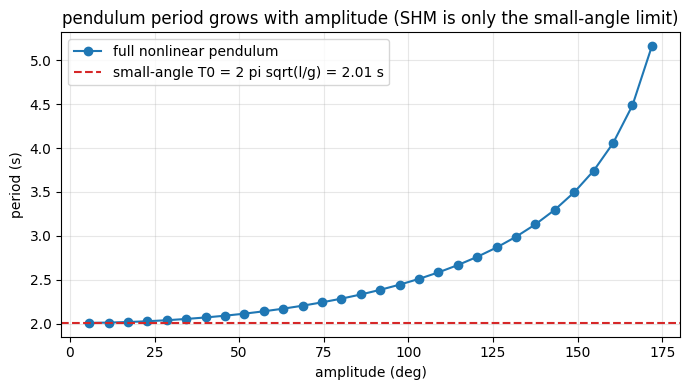

period at 10 deg = 2.011s (~T0), at 170 deg = 4.90s


In [3]:
g_, l_ = 9.8, 1.0; T0 = 2*np.pi*np.sqrt(l_/g_)        # small-angle period
def period(theta0, dt=1e-4):
    th, w = theta0, 0.0; tt = 0.0
    # quarter period: time from release (w=0) to the first zero crossing
    while th > 0:
        a = -(g_/l_)*np.sin(th)
        w += a*dt; th += w*dt; tt += dt
    return 4*tt
amps = np.linspace(0.1, 3.0, 30)
T = np.array([period(a) for a in amps])
plt.figure(figsize=(7,4))
plt.plot(np.degrees(amps), T, "o-", label="full nonlinear pendulum")
plt.axhline(T0, ls="--", color="C3", label=f"small-angle T0 = 2 pi sqrt(l/g) = {T0:.2f} s")
plt.xlabel("amplitude (deg)"); plt.ylabel("period (s)"); plt.legend()
plt.title("pendulum period grows with amplitude (SHM is only the small-angle limit)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"period at 10 deg = {period(np.radians(10)):.3f}s (~T0), at 170 deg = {period(np.radians(170)):.2f}s")

## 3. Coupled oscillators -> normal modes (the eigenvalue payoff)

Two masses joined by springs have a Lagrangian whose small-oscillation form is
$T=\tfrac12\dot{\mathbf q}^TM\dot{\mathbf q}$, $V=\tfrac12\mathbf q^TK\mathbf q$.
Solving $K\mathbf v=\omega^2M\mathbf v$ gives two **normal modes**: an in-phase mode at
$\sqrt{k/m}$ (the coupling spring never stretches) and an out-of-phase mode at
$\sqrt{(k+2k_c)/m}$ (the coupling fights the motion). Same generalized eigenproblem as
`dgs.eigen_modes`.

normal-mode frequencies: omega = [2.     2.6458]
  in-phase  sqrt(k/m)        = 2.0000
  out-phase sqrt((k+2kc)/m)  = 2.6458


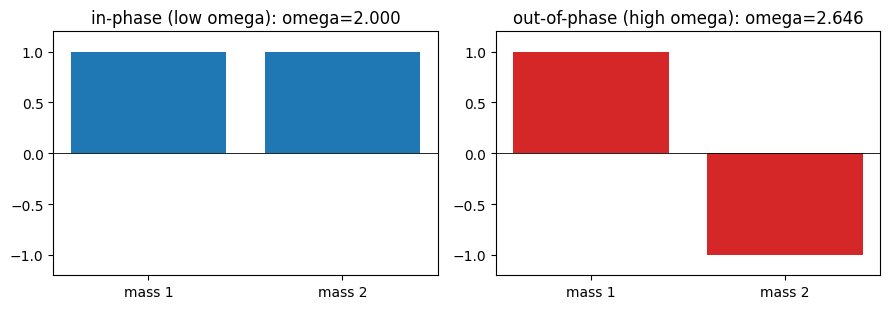

In [4]:
K, M = lag.coupled_oscillator_KM(m=1.0, k=4.0, k_c=1.5)
w = lag.normal_mode_frequencies(M, K)
vals, vecs = np.linalg.eig(np.linalg.solve(M, K))
order = np.argsort(vals.real); vecs = vecs[:, order]
print(f"normal-mode frequencies: omega = {np.round(w,4)}")
print(f"  in-phase  sqrt(k/m)        = {np.sqrt(4):.4f}")
print(f"  out-phase sqrt((k+2kc)/m)  = {np.sqrt(4+3):.4f}")
fig, ax = plt.subplots(1, 2, figsize=(9,3.2))
for j,(nm,col) in enumerate([("in-phase (low omega)","C0"),("out-of-phase (high omega)","C3")]):
    v = vecs[:,j].real; v = v/np.max(np.abs(v))
    ax[j].bar([0,1], v, color=col); ax[j].axhline(0,color="k",lw=0.6)
    ax[j].set(xticks=[0,1], xticklabels=["mass 1","mass 2"], ylim=(-1.2,1.2),
              title=f"{nm}: omega={w[j]:.3f}")
plt.tight_layout(); plt.show()

## What ties together

1. **Euler-Lagrange** turns one scalar $L=T-V$ into the equation of motion -- the
   oscillator, the pendulum, anything -- by differentiating energies, not summing
   forces.
2. **Small oscillations** about equilibrium are simple harmonic; the full pendulum is
   only approximately SHM (its period grows with amplitude).
3. **Coupled systems** linearize into $K\mathbf v=\omega^2M\mathbf v$ -- the **normal
   modes**, the same eigenvalue problem as `dgs.eigen_modes`, the Bessel drum, and the
   quantum box.

One principle (least action) underlies all of mechanics, and near equilibrium it is
eigenvalues all the way down. Civilian education.